# Классификация IC50 > медианы

Необходимо сравнить различные модели с настройкой гиперпараметров для бинарной классификации соединений по уровню их ингибирующей активности (IC50 выше или ниже медианы) на основе молекулярных дескрипторов.

Целевая переменная представляет собой бинарный признак, где 1 соответствует соединениям с IC50 выше медианы, а 0 - соединениям с IC50 ниже или равным медиане.

Такое преобразование регрессионной задачи в классификационную позволяет выявлять соединения с высокой потенциальной эффективностью и упрощает интерпретацию результатов для скрининга лекарственных кандидатов.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import VarianceThreshold

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Загрузка данных

In [ ]:
df = pd.read_csv('/data/clean_data.csv')
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


## Подготовка данных к обучению модели

Так как в исходном датасете отсутствует целевая переменная необходимая для данной задачи создадим ее. Затем разделим данные на X, где будут все признаки и y, где будет только что созданная целевая переменная.

Для того чтобы избежать утечки информации в модель, важно исключить из рассмотрения признаки 'IC50, mM' и 'SI'.

In [ ]:
# Формирование целевой переменной
median_ic50 = df['IC50, mM'].median()
df['IC50_high'] = (df['IC50, mM'] > median_ic50).astype(int)

X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'IC50_high'])
y = df['IC50_high']
X.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,...,0,0,0,0,0,0,0,0,3,0
1,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,...,0,0,0,0,0,0,0,0,3,0
2,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,186,...,0,0,0,0,0,0,0,0,3,0
3,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,164,...,0,0,0,0,0,0,0,0,4,0
4,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,184,...,0,0,0,0,0,0,0,0,0,0


Рассмотрим распределение целевой переменной и проверим сбалансированность классов:

In [ ]:
class_counts = df['IC50_high'].value_counts()
class_counts

,count
IC50_high,
0,485
1,484


Для наглядности визуализируем распределение признака IC50 на грфике и отобразим значение медианы. Дополнительно построим график распределения целевой переменной.

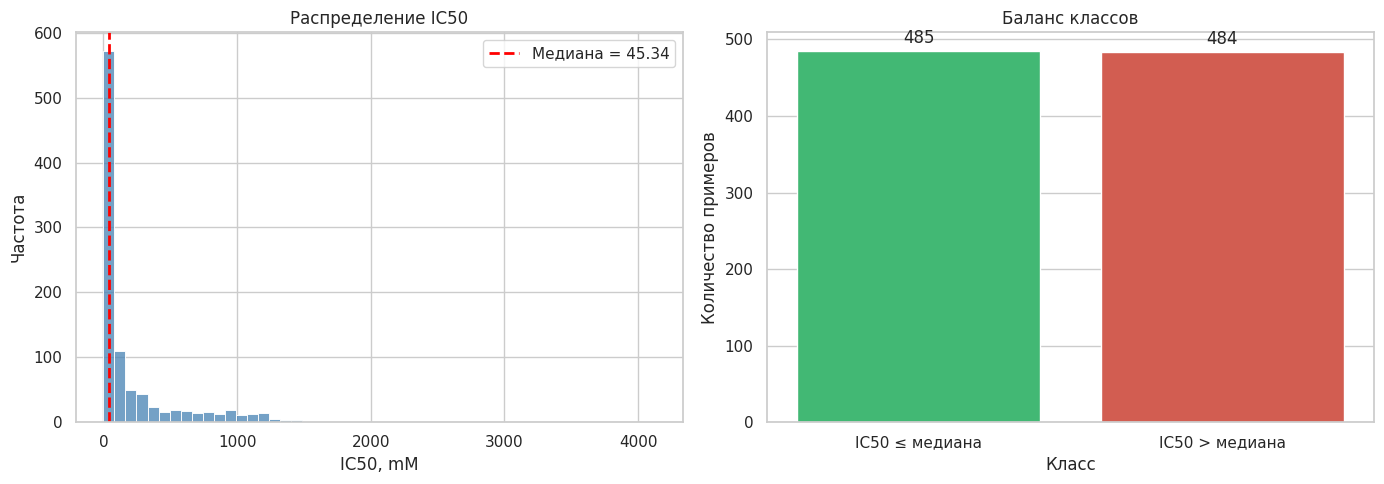

In [ ]:
sns.set(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Распределение IC50 с медианой
sns.histplot(df['IC50, mM'], bins=50, kde=False, color='steelblue', ax=ax1)
ax1.axvline(median_ic50, color='red', linestyle='--', linewidth=2, label=f'Медиана = {median_ic50:.2f}')
ax1.set_title('Распределение IC50')
ax1.set_xlabel('IC50, mM')
ax1.set_ylabel('Частота')
ax1.legend()

class_data = pd.DataFrame({
    'Классы': ['IC50 ≤ медиана', 'IC50 > медиана'],
    'Количество': class_counts.values
})
sns.barplot(data=class_data, x='Классы', y='Количество', hue='Классы',
            palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Баланс классов')
ax2.set_ylabel('Количество примеров')
ax2.set_xlabel('Класс')

# Добавление подписей на столбцы
for i, v in enumerate(class_counts.values):
    ax2.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

На левом графику выше определил медианное значение, равное 45.34 mM. Также по правому графику можно сделать вывод о том, что классы распределены равномерно и дополнительной обработки данных не требуется.

Разделим данные на тренировочную и тестовую выборки в соотношении 80 к 20:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
X_train.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
655,6.392531,6.392531,0.036474,-0.109860,0.635744,36.571429,300.427,280.267,300.129634,110,...,0,0,0,0,0,0,0,0,0,0
461,12.197500,12.197500,0.138253,-0.138253,0.213572,16.432432,500.563,472.339,500.228437,190,...,0,0,0,0,0,0,0,0,0,0
92,5.503519,5.503519,0.397743,0.397743,0.715571,35.555556,250.430,220.190,250.240899,104,...,0,0,0,0,0,0,0,0,3,0
538,15.011816,15.011816,0.011442,-1.589981,0.183480,14.424242,452.432,433.280,452.134777,168,...,0,0,0,0,0,0,0,0,0,0
937,14.703133,14.703133,0.079140,-1.408431,0.263934,15.104167,660.787,615.427,660.332313,256,...,0,0,0,0,0,0,0,0,0,0


Дополнительно обработаем данные с помощью VarianceThreshold, который позволит нам удалить константные признаки, так как такие признаки не несут никакой полезной информации для предсказания (их дисперсия = 0), но по сравнению с другими задачами в данной задаче негативно влияют на предсказания модели, создавая шум.

In [ ]:
# Удаляем признаки с нулевой дисперсией
selector_var = VarianceThreshold(threshold=0)
X_train = selector_var.fit_transform(X_train)
X_test = selector_var.transform(X_test)

# Получаем оставшиеся признаки
remaining_features = X.columns[selector_var.get_support()]
print(f"Осталось признаков: {len(remaining_features)}")

Осталось признаков: 190


## Обучение моделей

Для данной задачи будем рассматривать 4 различные модели классификации: логистическая регрессия, случайный лес, градиентный бустинг и XGBoost.

Для каждой модели проводится подбор гиперпараметров с помощью GridSearchCV и кросс-валидации, в качестве метрики оптимизации выбрана площадь под ROC-кривой (ROC-AUC).

Оценивать качество моделей будем по трем метрикам:

- точность (Accuracy)

- F1-мера (F1-score)

- площадь под ROC-кривой (ROC-AUC)

Логистическая регрессия предваряется стандартизацией признаков с помощью StandardScaler в составе конвейера. Все модели используют фиксированный random_state=42 для воспроизводимости результатов.



In [ ]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba)
    }

Выше представлена общая функция для предсказания и оценки модели. После подбора гиперпараметров для каждой модели извлекаются лучшие параметры, затем модели оцениваются на тестовой выборке по всем трем метрикам.

**Логистическая регрессия**

In [ ]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

params_log = {
    'model__C': [0.01, 0.1, 1, 10]
}

grid_log = GridSearchCV(logreg, params_log, cv=5, scoring='roc_auc')
grid_log.fit(X_train, y_train)

res_log = evaluate(grid_log.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_log.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_log.best_score_:.4f}")

Лучшие параметры: {'model__C': 0.01}
Наилучшая метрика ROC-AUC: 0.7408


**Случайный лес**

In [ ]:
rf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, params_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

res_rf = evaluate(grid_rf.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_rf.best_score_:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Наилучшая метрика ROC-AUC: 0.7552


**Градиентный бустинг**

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

params_gb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(gb, params_gb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)

res_gb = evaluate(grid_gb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_gb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Наилучшая метрика ROC-AUC: 0.7559


**XGBoost**

In [ ]:
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

params_xgb = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb_clf, params_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

res_xgb = evaluate(grid_xgb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_xgb.best_params_}")
print(f"Наилучшая метрика ROC-AUC: {grid_xgb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Наилучшая метрика ROC-AUC: 0.7713


Соберем датафрейм с результатами моделей:

In [ ]:
results = pd.DataFrame({
    'LogReg': res_log,
    'RandomForest': res_rf,
    'GradientBoosting': res_gb,
    'XGBoost': res_xgb
}).T

results.sort_values('ROC_AUC', ascending=False)

,Accuracy,F1,ROC_AUC
RandomForest,0.747423,0.753769,0.827665
GradientBoosting,0.737113,0.741117,0.814380
XGBoost,0.721649,0.730000,0.813848
LogReg,0.716495,0.720812,0.771761


Среди четырех рассмотренных моделей классификации лучший результат показал RandomForest, достигнув ROC-AUC = 0.828. GradientBoosting занял второе место незначительно уступив случайному лесу по всем метрикам. XGBoost показал результаты, близкие к градиентному бустингу, в то время как логистическая регрессия оказалась наихудшей, что объясняется нелинейным характером зависимости между молекулярными дескрипторами и бинарной активностью IC50.

Все модели демонстрируют хорошую разделяющую способность - значения ROC-AUC в диапазоне 0.77-0.83 указывают на хорошее качество бинарной классификации. Стоит обратить внимание на то, что GradientBoosting и XGBoost показывают практически идентичные значения ROC-AUC, однако XGBoost уступает по точности, что может быть связано с различными стратегиями регуляризации.

**Рекомендация**

В качестве финальной модели для предсказания IC50 > медианы рекомендуется использовать RandomForest как лучший по всем трем метрикам. Для повышения качества можно дополнительно настроить гиперпараметры через более широкую сетку поиска, например, увеличить количество деревьев до 500. Также стоит рассмотреть ансамблирование топ-3 моделей через голосование для потенциального улучшения ROC-AUC. При необходимости интерпретируемости можно использовать логистическую регрессию с нелинейными признаками.

